#### Visualizing distributions of data

An early step in any effort to analyze or model data should be to understand how the variables are distributed. Techniques for distribution visualization can provide quick answers to many important questions. What range do the observations cover? What is their central tendency? Are they heavily skewed in one direction? Is there evidence for bimodality? Are there significant outliers? Do the answers to these questions vary across subsets defined by other variables?

The distributions module contains several functions designed to answer questions such as these. The axes-level functions are histplot(), kdeplot(), ecdfplot(), and rugplot(). They are grouped together within the figure-level displot(), jointplot(), and pairplot() functions.

There are several different approaches to visualizing a distribution, and each has its relative advantages and drawbacks. It is important to understand these factors so that you can choose the best approach for your particular aim.

Plotting univariate histograms

In [3]:
import seaborn as sns

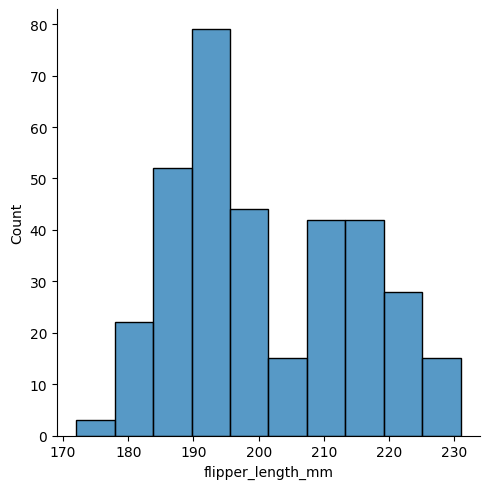

In [4]:
penguins = sns.load_dataset("penguins")
sns.displot(penguins, x="flipper_length_mm")

Choosing the bin size

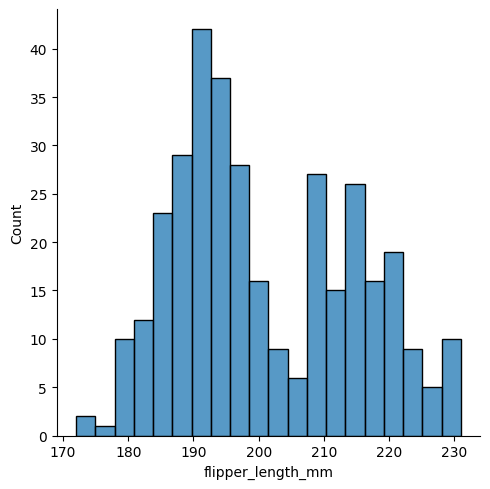

In [5]:
sns.displot(penguins, x="flipper_length_mm", binwidth=3)

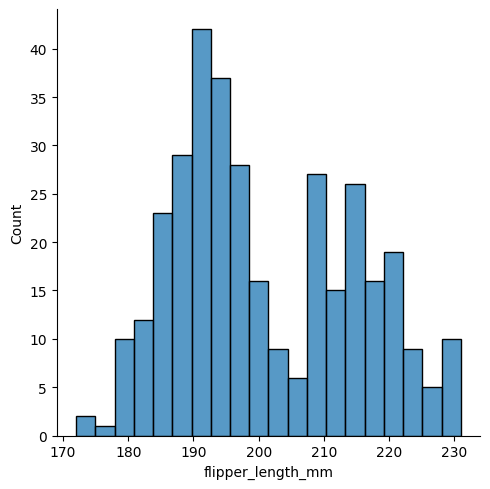

In [6]:
sns.displot(penguins, x="flipper_length_mm", bins=20)

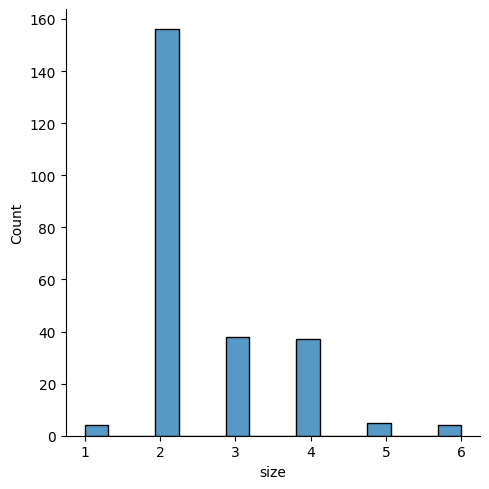

In [7]:
tips = sns.load_dataset("tips")
sns.displot(tips, x="size")

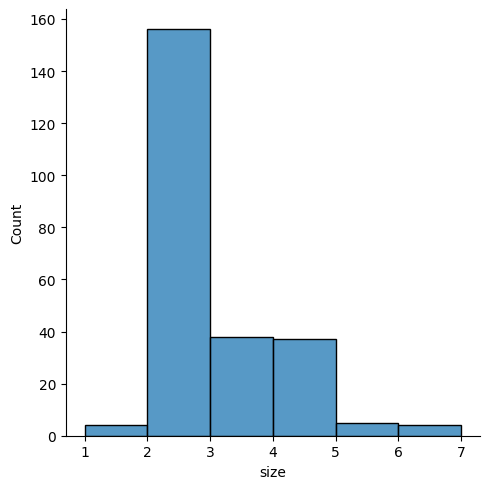

In [8]:
sns.displot(tips, x="size", bins=[1, 2, 3, 4, 5, 6, 7])

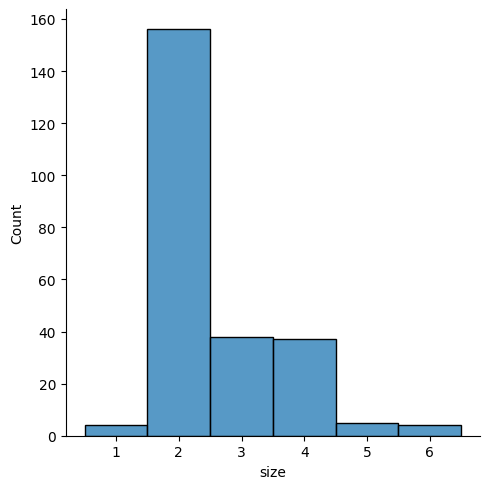

In [9]:
sns.displot(tips, x="size", discrete=True)

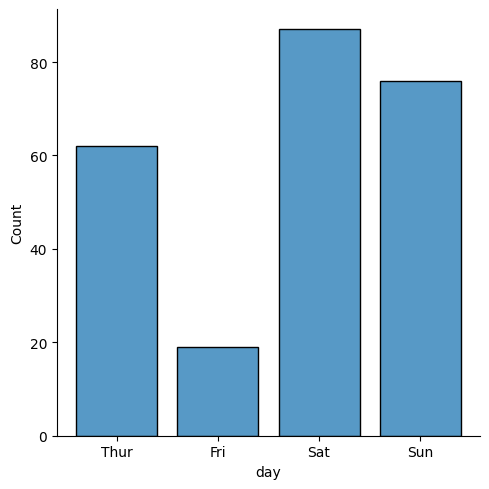

In [10]:
sns.displot(tips, x="day", shrink=.8)

#### Conditioning on other variables

Once you understand the distribution of a variable, the next step is often to ask whether features of that distribution differ across other variables in the dataset. For example, what accounts for the bimodal distribution of flipper lengths that we saw above? displot() and histplot() provide support for conditional subsetting via the hue semantic. Assigning a variable to hue will draw a separate histogram for each of its unique values and distinguish them by color:

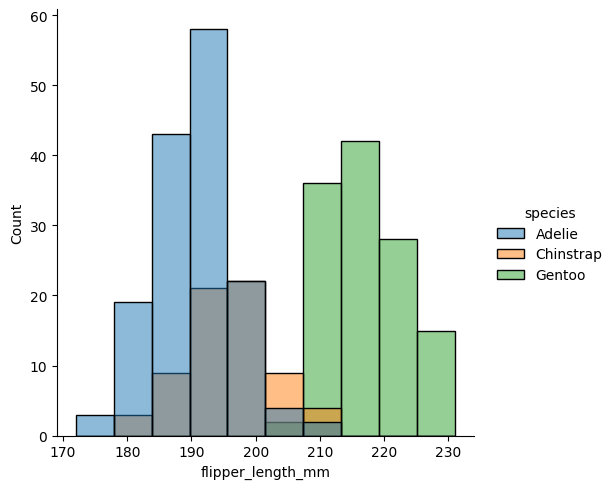

In [11]:
sns.displot(penguins, x="flipper_length_mm", hue="species")

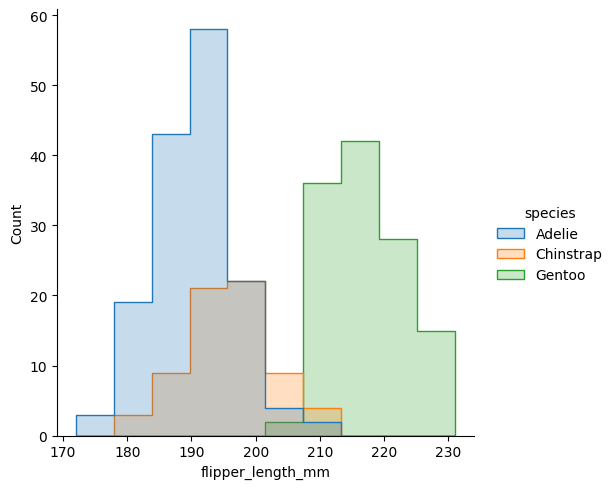

In [12]:
sns.displot(penguins, x="flipper_length_mm", hue="species", element="step")

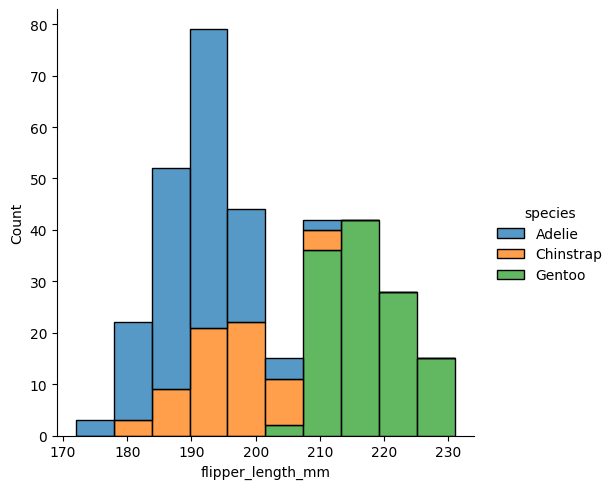

In [13]:
sns.displot(penguins, x="flipper_length_mm", hue="species", multiple="stack")

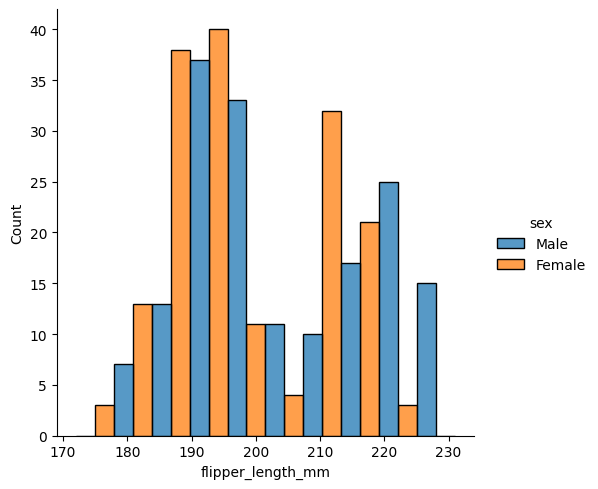

In [14]:
sns.displot(penguins, x="flipper_length_mm", hue="sex", multiple="dodge")

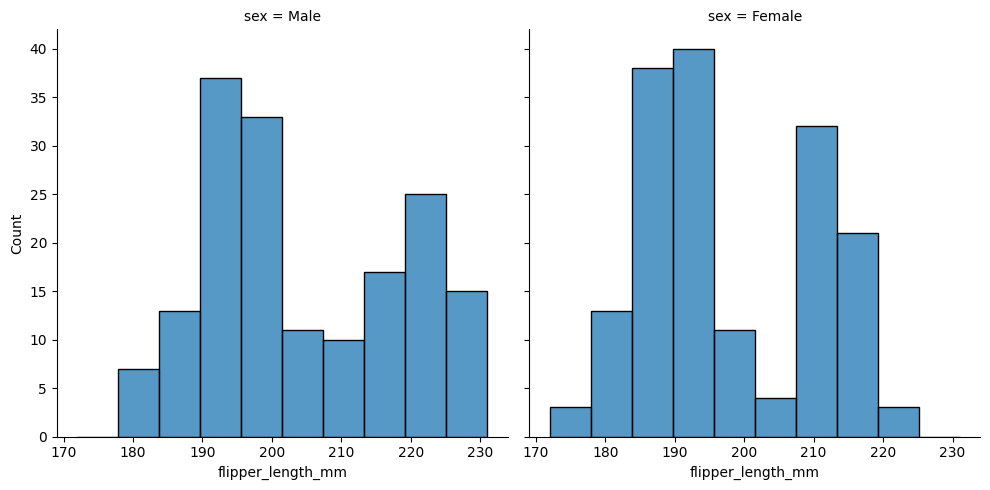

In [15]:
sns.displot(penguins, x="flipper_length_mm", col="sex")

#### Normalized histogram statistics

Before we do, another point to note is that, when the subsets have unequal numbers of observations, comparing their distributions in terms of counts may not be ideal. One solution is to normalize the counts using the stat parameter:

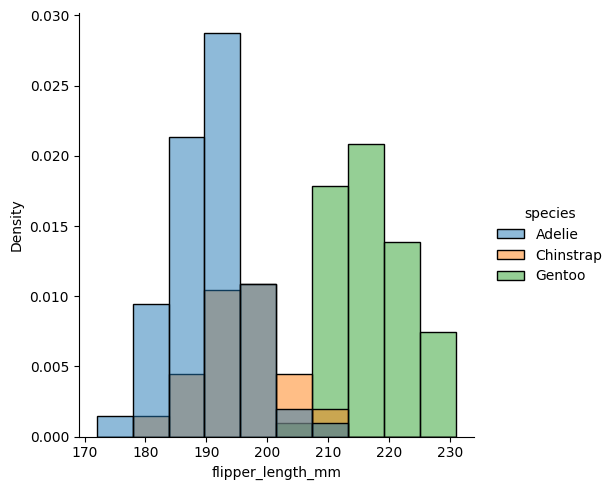

In [16]:
sns.displot(penguins, x="flipper_length_mm", hue="species", stat="density")

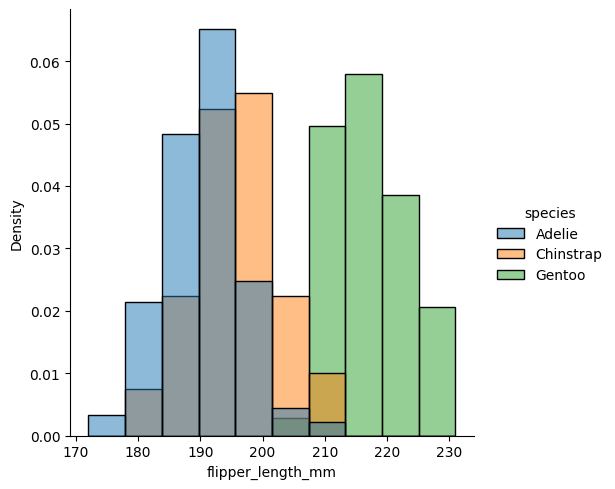

In [17]:
sns.displot(penguins, x="flipper_length_mm", hue="species", stat="density", common_norm=False)

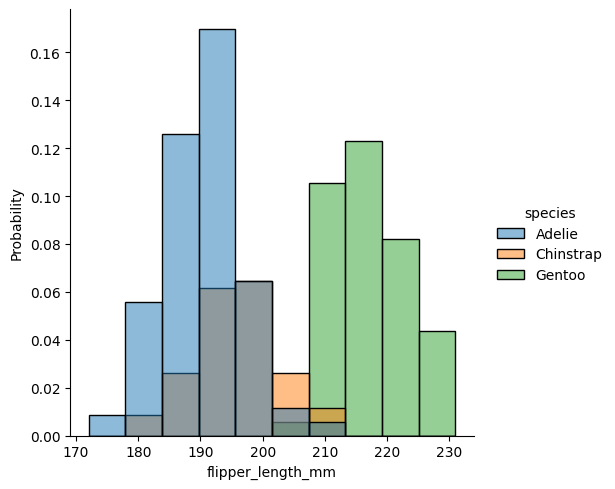

In [18]:
sns.displot(penguins, x="flipper_length_mm", hue="species", stat="probability")

Kernel density estimation

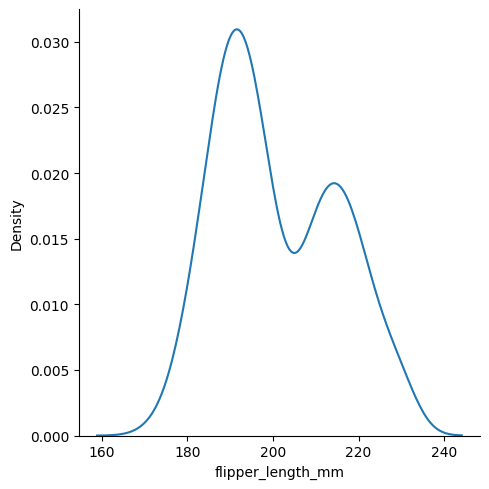

In [19]:
sns.displot(penguins, x="flipper_length_mm", kind="kde")

Choosing the smoothing bandwidth

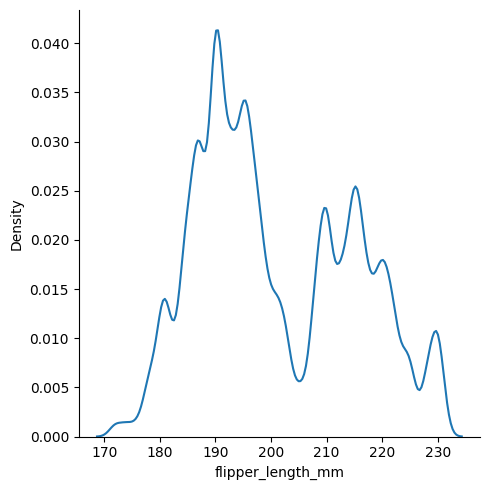

In [20]:
sns.displot(penguins, x="flipper_length_mm", kind="kde", bw_adjust=.25)

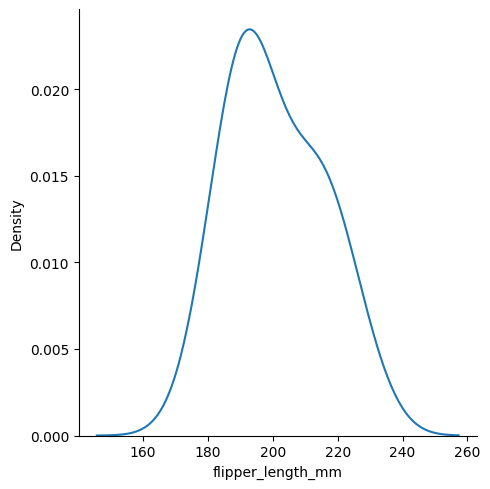

In [21]:
sns.displot(penguins, x="flipper_length_mm", kind="kde", bw_adjust=2)

Conditioning on other variables

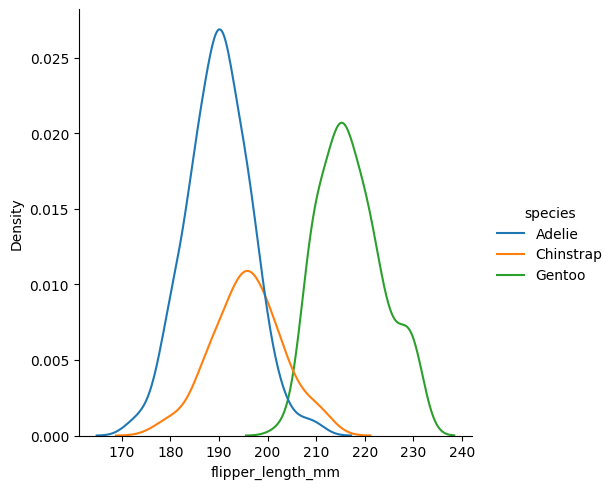

In [22]:
sns.displot(penguins, x="flipper_length_mm", hue="species", kind="kde")

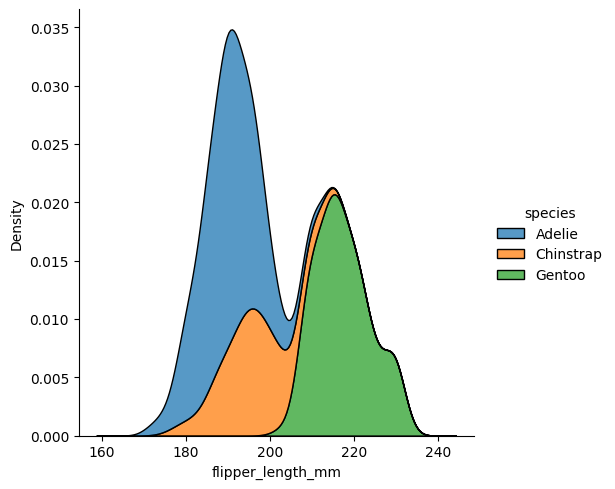

In [23]:
sns.displot(penguins, x="flipper_length_mm", hue="species", kind="kde", multiple="stack")

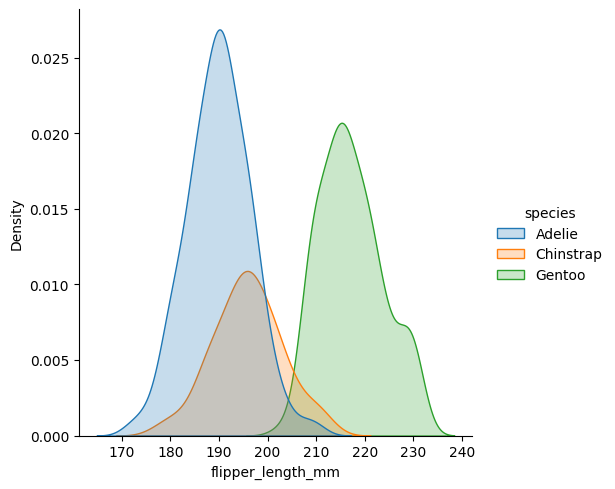

In [24]:
sns.displot(penguins, x="flipper_length_mm", hue="species", kind="kde", fill=True)

#### Kernel density estimation pitfalls

KDE plots have many advantages. Important features of the data are easy to discern (central tendency, bimodality, skew), and they afford easy comparisons between subsets. But there are also situations where KDE poorly represents the underlying data. This is because the logic of KDE assumes that the underlying distribution is smooth and unbounded. One way this assumption can fail is when a variable reflects a quantity that is naturally bounded. If there are observations lying close to the bound (for example, small values of a variable that cannot be negative), the KDE curve may extend to unrealistic values:

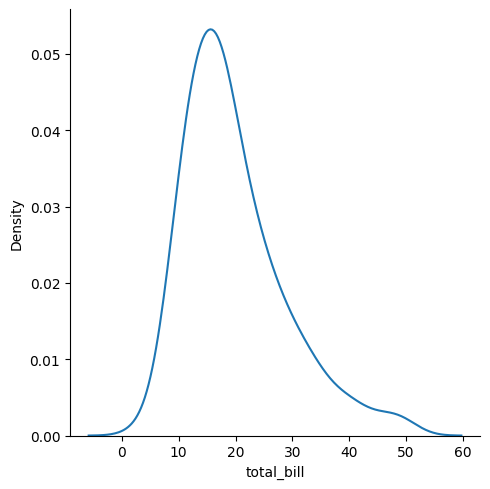

In [25]:
sns.displot(tips, x="total_bill", kind="kde")

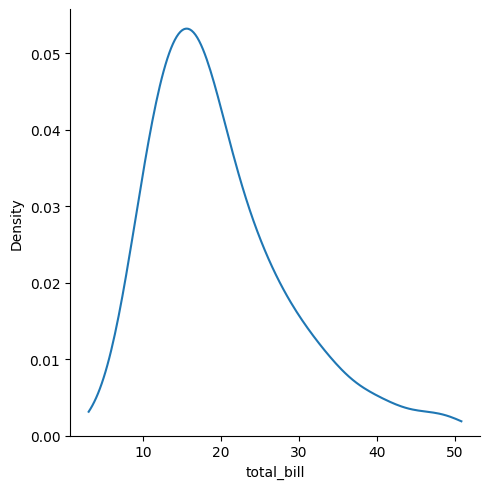

In [26]:
sns.displot(tips, x="total_bill", kind="kde", cut=0)

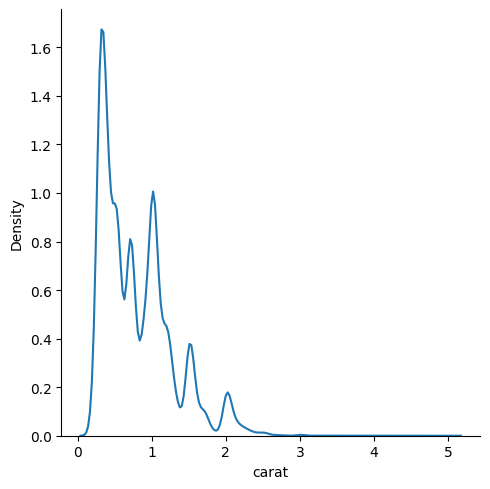

In [27]:
diamonds = sns.load_dataset("diamonds")
sns.displot(diamonds, x="carat", kind="kde")

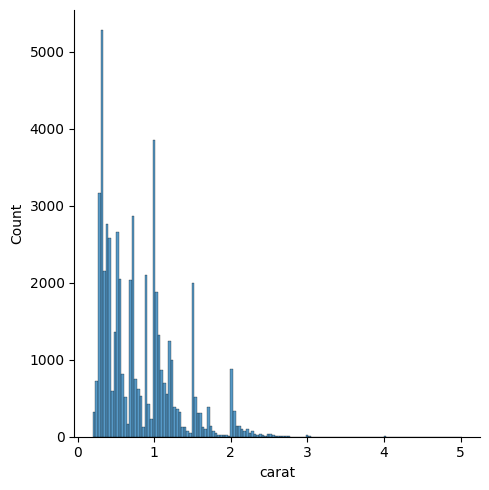

In [28]:
sns.displot(diamonds, x="carat")

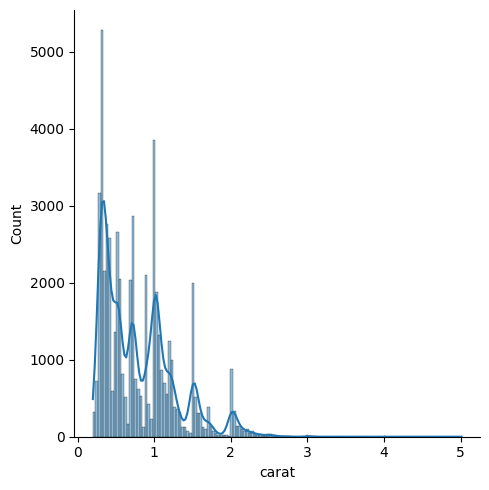

In [29]:
sns.displot(diamonds, x="carat", kde=True)

Empirical cumulative distributions

A third option for visualizing distributions computes the “empirical cumulative distribution function” (ECDF). This plot draws a monotonically-increasing curve through each datapoint such that the height of the curve reflects the proportion of observations with a smaller value:

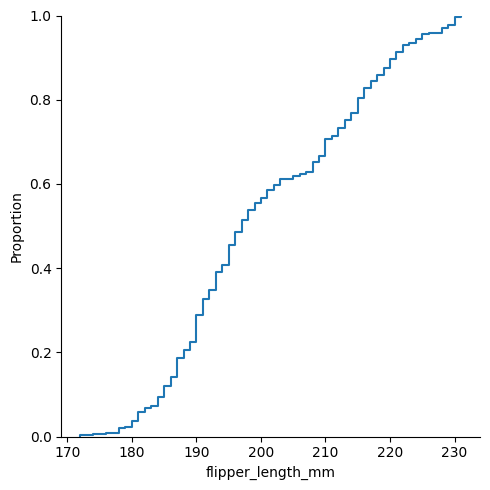

In [30]:
sns.displot(penguins, x="flipper_length_mm", kind="ecdf")

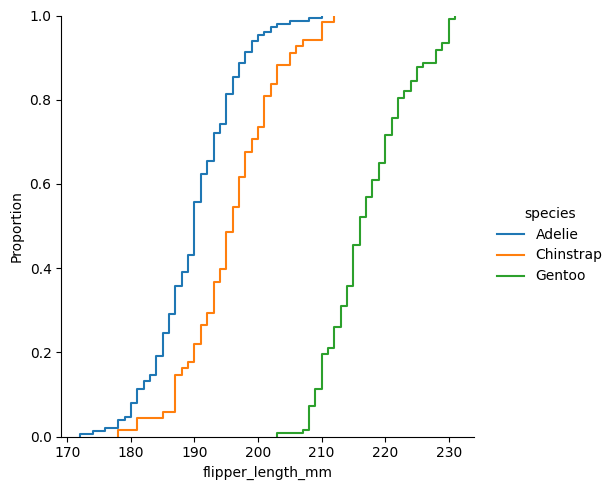

In [31]:
sns.displot(penguins, x="flipper_length_mm", hue="species", kind="ecdf")

Visualizing bivariate distributions

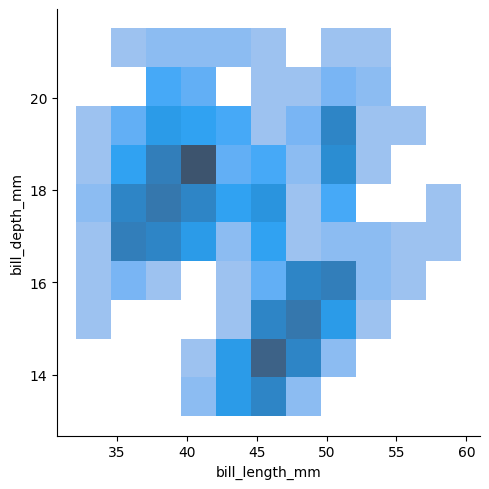

In [32]:
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm")

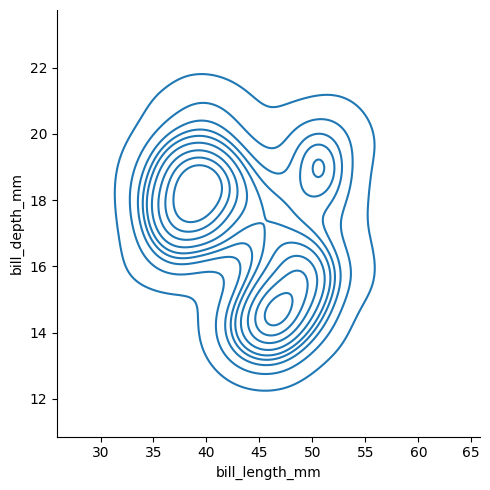

In [33]:
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", kind="kde")

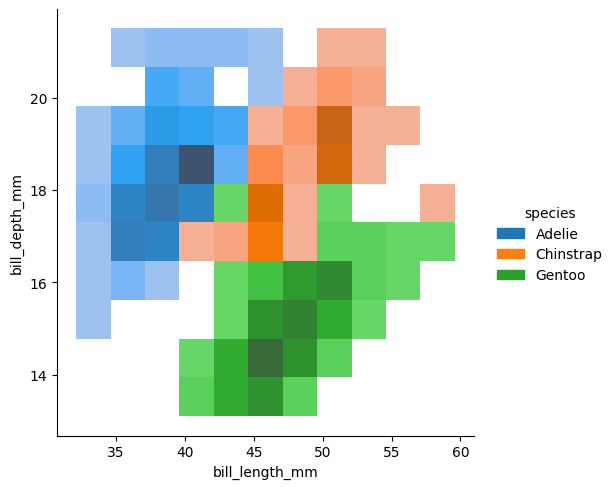

In [34]:
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", hue="species")

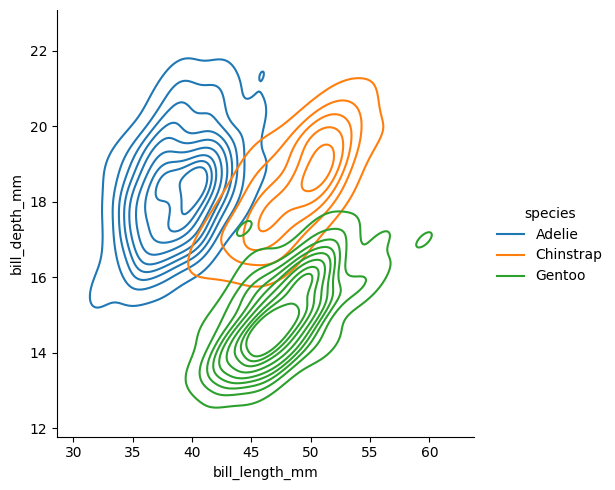

In [35]:
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", kind="kde")

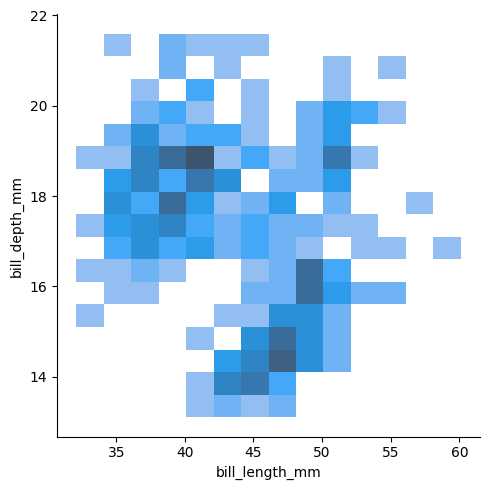

In [36]:
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", binwidth=(2, .5))

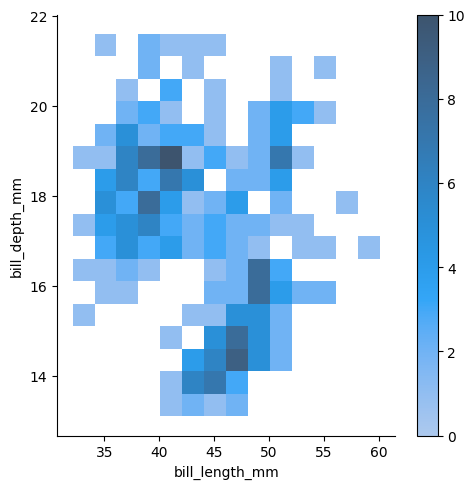

In [37]:
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", binwidth=(2, .5), cbar=True)

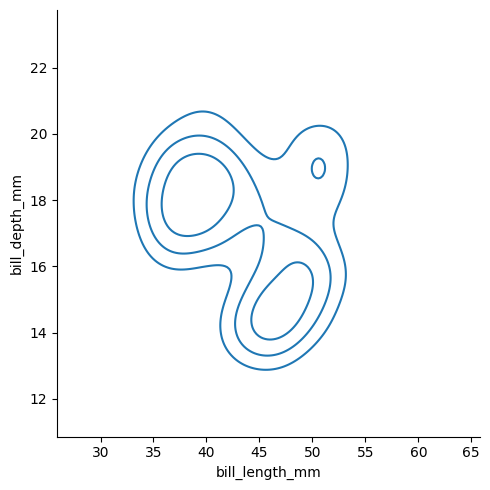

In [38]:
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", kind="kde", thresh=.2, levels=4)

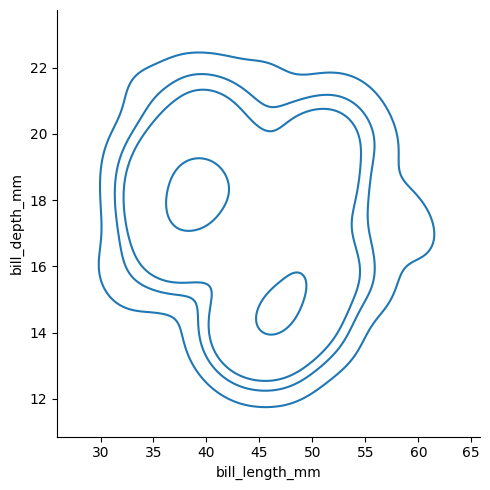

In [39]:
sns.displot(penguins, x="bill_length_mm", y="bill_depth_mm", kind="kde", levels=[.01, .05, .1, .8])

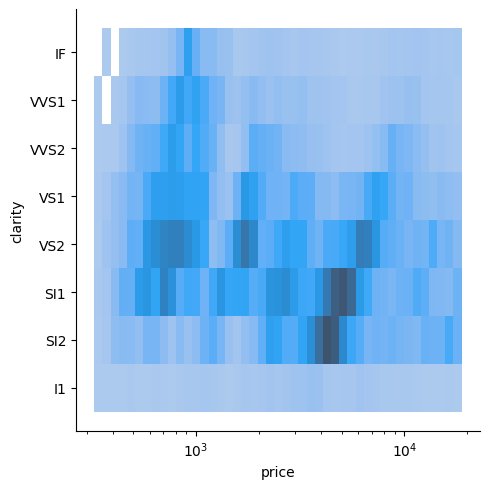

In [40]:
sns.displot(diamonds, x="price", y="clarity", log_scale=(True, False))

Distribution visualization in other settings

Plotting joint and marginal distributions

The first is jointplot(), which augments a bivariate relational or distribution plot with the marginal distributions of the two variables. By default, jointplot() represents the bivariate distribution using scatterplot() and the marginal distributions using histplot():

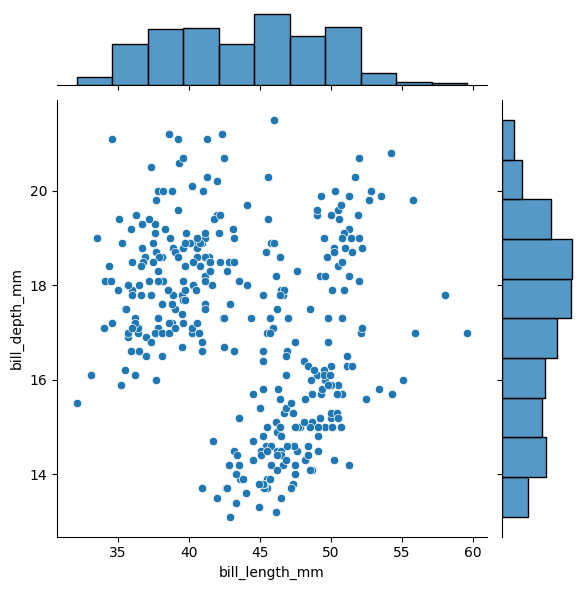

In [41]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")

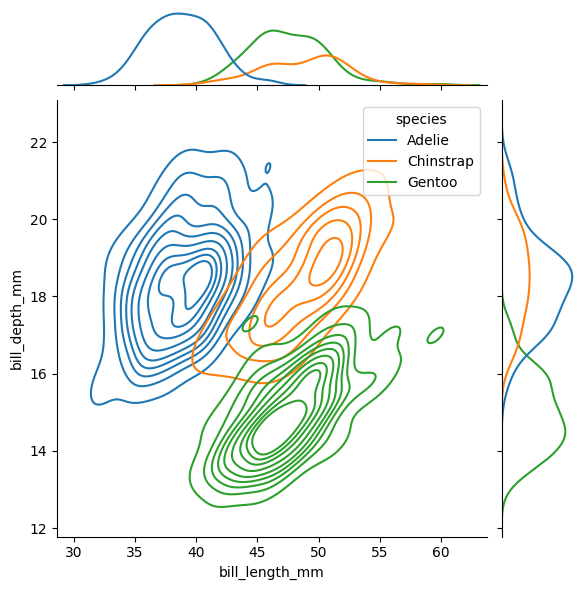

In [42]:
sns.jointplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm", hue="species",
    kind="kde"
)

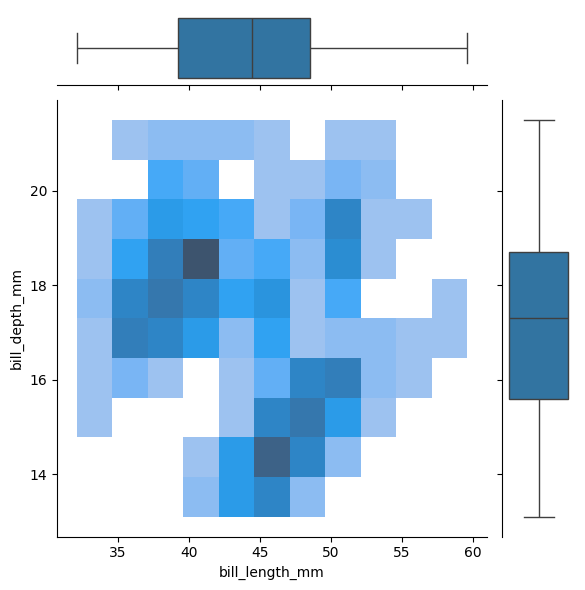

In [43]:
g = sns.JointGrid(data=penguins, x="bill_length_mm", y="bill_depth_mm")
g.plot_joint(sns.histplot)
g.plot_marginals(sns.boxplot)

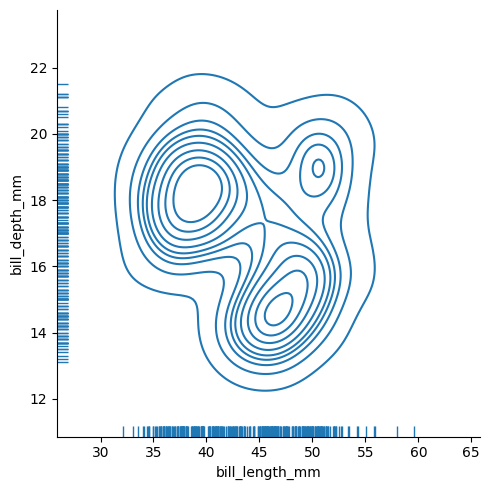

In [44]:
sns.displot(
    penguins, x="bill_length_mm", y="bill_depth_mm",
    kind="kde", rug=True
)

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

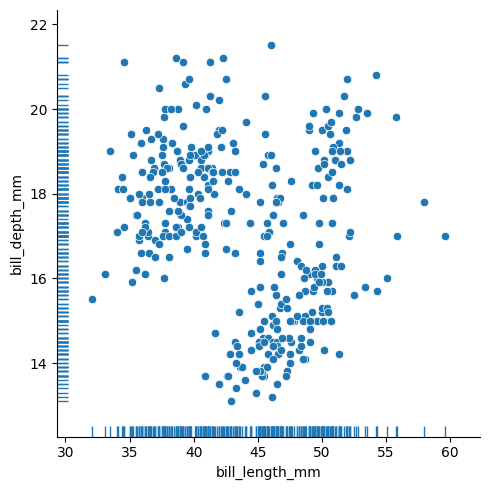

In [45]:
sns.relplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")
sns.rugplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")

Plotting many distributions

The pairplot() function offers a similar blend of joint and marginal distributions. Rather than focusing on a single relationship, however, pairplot() uses a “small-multiple” approach to visualize the univariate distribution of all variables in a dataset along with all of their pairwise relationships:

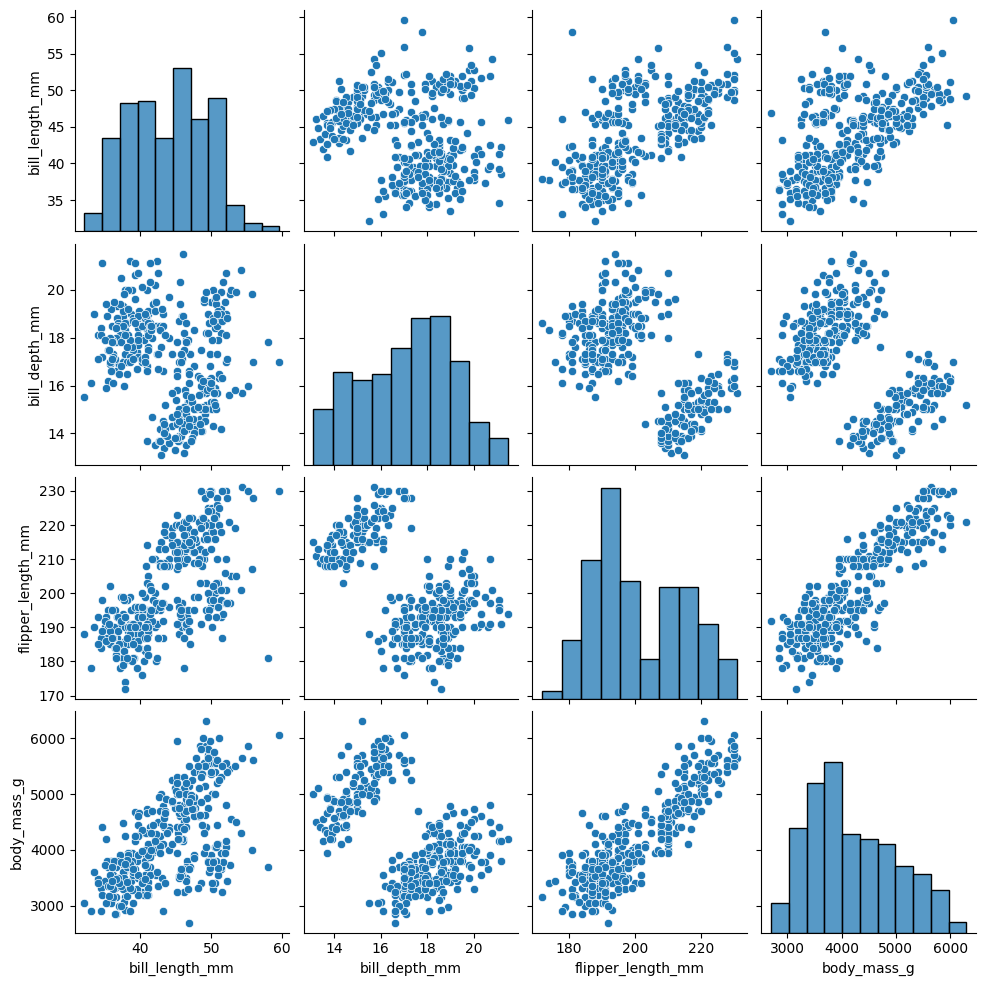

In [46]:
sns.pairplot(penguins)

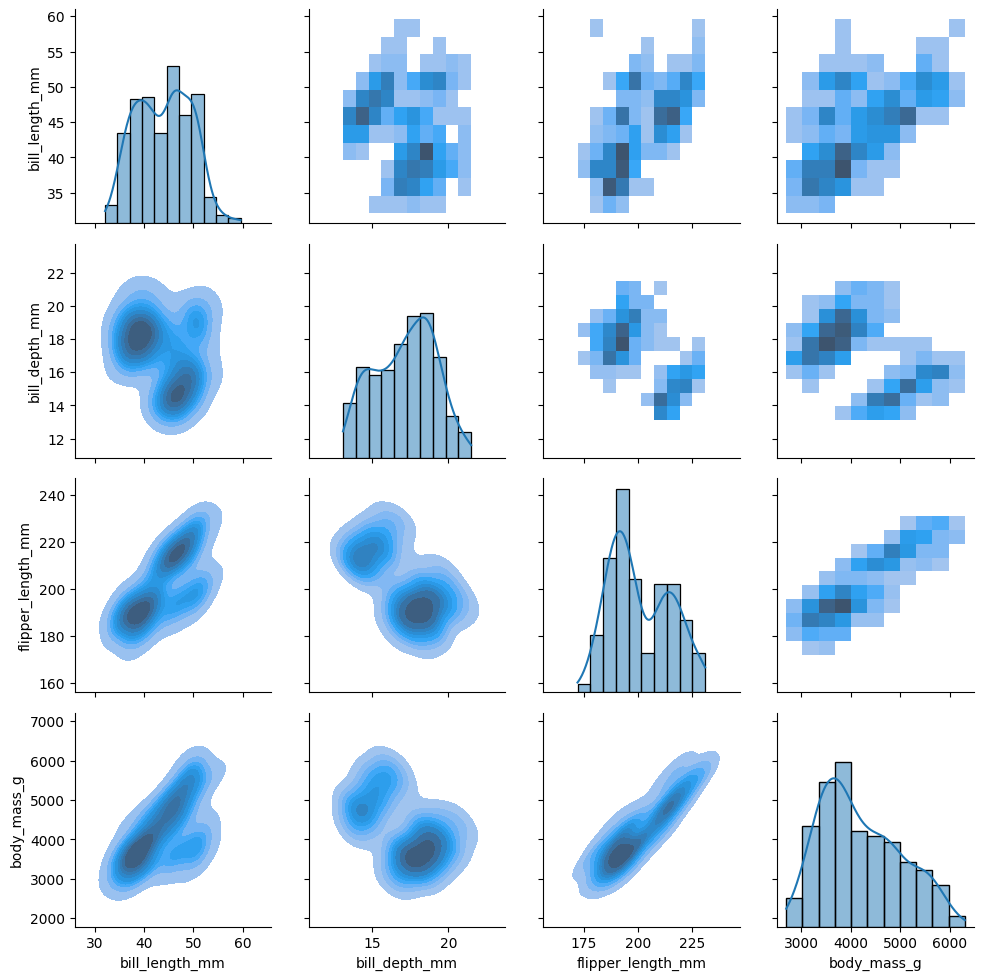

In [47]:
g = sns.PairGrid(penguins)
g.map_upper(sns.histplot)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot, kde=True)